# TextBlob Sentiment Analysis with Naive Bayes Models

# Import and setup


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\amirb\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



📊 Sentiment Counts (Train):
Sentiment
Neutral     4027
Positive    2253
Negative     770
Name: count, dtype: int64

📊 Sentiment Counts (Test):
Sentiment
Neutral     991
Positive    571
Negative    201
Name: count, dtype: int64

=== Training ComplementNB ===
Fitting 5 folds for each of 24 candidates, totalling 120 fits
ComplementNB Best Validation F1: 0.7749
ComplementNB Best Parameters: {'nb__alpha': 0.5, 'tfidf__max_df': 0.8, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}

=== Training GaussianNB ===
Fitting 5 folds for each of 8 candidates, totalling 40 fits
GaussianNB Best Validation F1: 0.4648
GaussianNB Best Parameters: {'tfidf__max_df': 0.8, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}

=== Training BernoulliNB ===
Fitting 5 folds for each of 24 candidates, totalling 120 fits
BernoulliNB Best Validation F1: 0.8333
BernoulliNB Best Parameters: {'nb__alpha': 0.1, 'tfidf__max_df': 0.8, 'tfidf__min_df': 5, 'tfidf__ngram_range': (1, 1)}

=== Final Evaluation on ChatGPT Test S

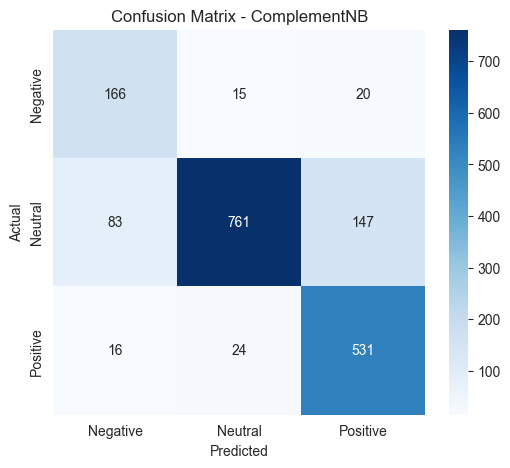


🔍 GaussianNB Test Performance:
Accuracy: 0.4663
Classification Report:
              precision    recall  f1-score   support

    Negative       0.14      0.54      0.23       201
     Neutral       0.77      0.35      0.48       991
    Positive       0.66      0.64      0.65       571

    accuracy                           0.47      1763
   macro avg       0.52      0.51      0.45      1763
weighted avg       0.66      0.47      0.51      1763



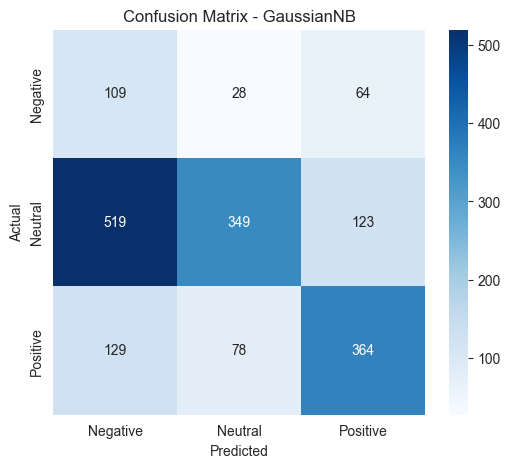


🔍 BernoulliNB Test Performance:
Accuracy: 0.9024
Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.65      0.72       201
     Neutral       0.95      0.94      0.94       991
    Positive       0.85      0.93      0.89       571

    accuracy                           0.90      1763
   macro avg       0.87      0.84      0.85      1763
weighted avg       0.90      0.90      0.90      1763



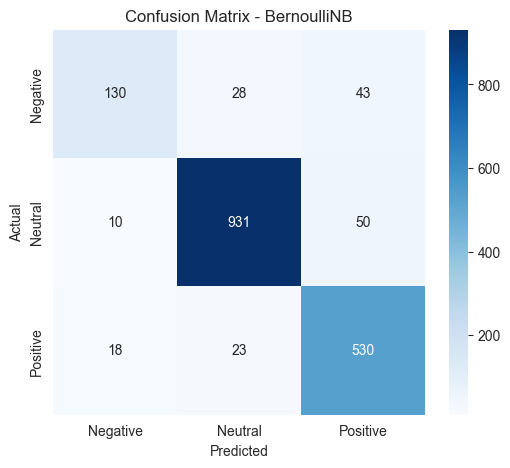

In [1]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB, GaussianNB, BernoulliNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.base import BaseEstimator, TransformerMixin
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
import joblib
import numpy as np

# Setup
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Utility Functions
def preprocess_text(text):
    if not isinstance(text, str):
        return []
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower().strip()
    words = text.split()
    return [word for word in words if word not in stop_words and len(word) > 2]

def plot_sentiment_distribution(df, title):
    plt.figure(figsize=(8, 5))
    sns.countplot(
        x=df['Sentiment'],
        palette='coolwarm',
        order=['Positive', 'Neutral', 'Negative']
    )
    plt.title(title)
    plt.xlabel("Sentiment")
    plt.ylabel("Count")
    plt.show()

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Negative', 'Neutral', 'Positive'],
        yticklabels=['Negative', 'Neutral', 'Positive']
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Load datasets (assumes they already have 'Sentiment' column)
train_df = pd.read_csv('train_dataset_chatgpt.csv')
test_df = pd.read_csv('test_dataset_chatgpt.csv')

train_df['Final_Comment'] = train_df['Final_Comment'].astype(str)
test_df['Final_Comment'] = test_df['Final_Comment'].astype(str)

# Create numerical labels
sentiment_mapping = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
train_df['Sentiment_Label'] = train_df['Sentiment'].map(sentiment_mapping)
test_df['Sentiment_Label'] = test_df['Sentiment'].map(sentiment_mapping)

train_df.dropna(subset=['Sentiment_Label'], inplace=True)
test_df.dropna(subset=['Sentiment_Label'], inplace=True)

train_df['Sentiment_Label'] = train_df['Sentiment_Label'].astype(int)
test_df['Sentiment_Label'] = test_df['Sentiment_Label'].astype(int)

# Display numerical sentiment distribution (counts)
print("\n📊 Sentiment Counts (Train):")
print(train_df['Sentiment'].value_counts())
print("\n📊 Sentiment Counts (Test):")
print(test_df['Sentiment'].value_counts())

# First create the proper train/val/test splits
X = train_df['Final_Comment']
y = train_df['Sentiment_Label']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Define test set (from the separate test_df)
X_test = test_df['Final_Comment']
y_test = test_df['Sentiment_Label']

# Create a proper transformer for dense conversion
class DenseTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.toarray()

# Updated models dictionary
models = {
    'ComplementNB': Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('nb', ComplementNB())
    ]),
    'GaussianNB': Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('to_dense', DenseTransformer()),
        ('scaler', MinMaxScaler()),
        ('nb', GaussianNB())
    ]),
    'BernoulliNB': Pipeline([
        ('tfidf', TfidfVectorizer(binary=True)),
        ('nb', BernoulliNB())
    ])
}

# Model-specific parameter grids
param_grids = {
    'ComplementNB': {
        'tfidf__max_df': [0.8, 1.0],
        'tfidf__min_df': [1, 5],
        'tfidf__ngram_range': [(1, 1), (1, 2)],
        'nb__alpha': [0.1, 0.5, 1.0]
    },
    'GaussianNB': {
        'tfidf__max_df': [0.8, 1.0],
        'tfidf__min_df': [1, 5],
        'tfidf__ngram_range': [(1, 1), (1, 2)]
    },
    'BernoulliNB': {
        'tfidf__max_df': [0.8, 1.0],
        'tfidf__min_df': [1, 5],
        'tfidf__ngram_range': [(1, 1), (1, 2)],
        'nb__alpha': [0.1, 0.5, 1.0]
    }
}

results = {}

for name, model in models.items():
    print(f"\n=== Training {name} ===")
    grid = GridSearchCV(
        model,
        param_grids[name],
        cv=5,
        scoring='f1_macro',
        verbose=2,
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    # Store results
    results[name] = {
        'best_params': grid.best_params_,
        'best_score': grid.best_score_,
        'model': grid.best_estimator_,
        'val_predictions': grid.predict(X_val),
        'val_accuracy': accuracy_score(y_val, grid.predict(X_val))
    }

    print(f"{name} Best Validation F1: {grid.best_score_:.4f}")
    print(f"{name} Best Parameters: {grid.best_params_}")

# After all models are trained, evaluate on test set
print("\n=== Final Evaluation on ChatGPT Test Set ===")
for name, res in results.items():
    # Get test predictions
    y_pred = res['model'].predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Neutral", "Positive"],
        output_dict=True
    )

    # Update results with test metrics
    results[name]['test_predictions'] = y_pred
    results[name]['test_accuracy'] = accuracy
    results[name]['test_report'] = report

    print(f"\n🔍 {name} Test Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Neutral", "Positive"]
    ))
     # Plot confusion matrix for each model
    plot_confusion_matrix(y_test, y_pred, f"Confusion Matrix - {name}")
    
        # Save classification report to JSON
    with open(f"classification_report_{name.lower()}_chatgpt.json", "w") as f:
        json.dump(report, f, indent=2)


    # Save classification report to JSON
    with open(f"classification_report_{name.lower()}_chatgpt.json", "w") as f:
        json.dump(report, f, indent=2)

C:\Users\amirb\AppData\Local\Temp\ipykernel_7220\2230078221.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


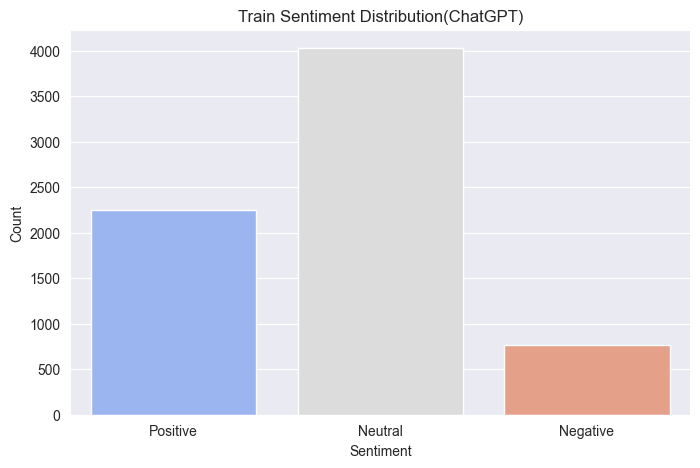

C:\Users\amirb\AppData\Local\Temp\ipykernel_7220\2230078221.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


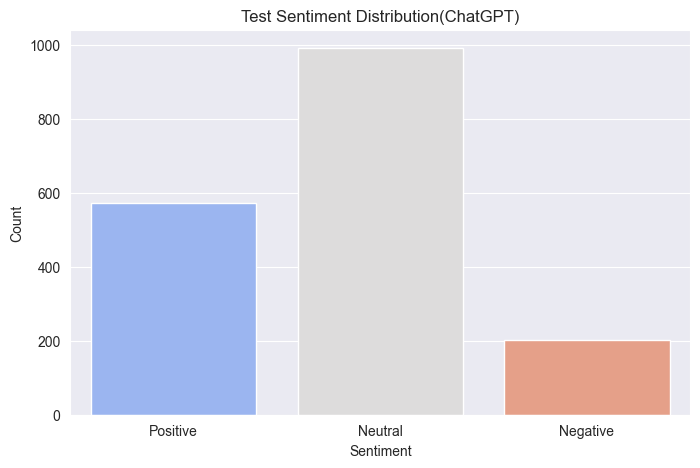


 Best Model: BernoulliNB with validation F1: 0.8333


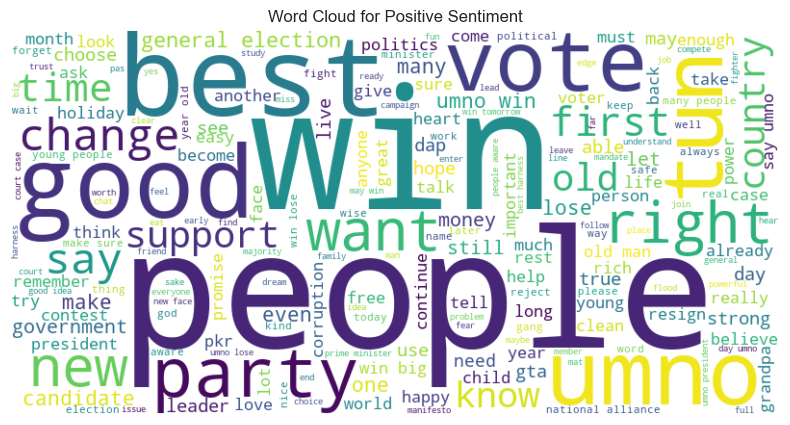

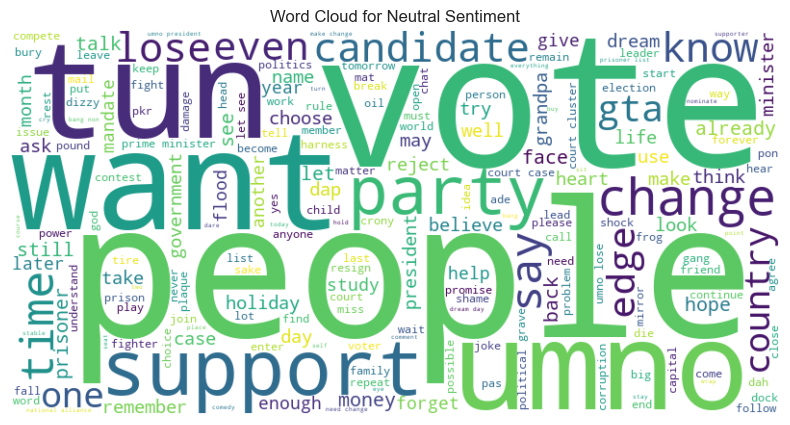

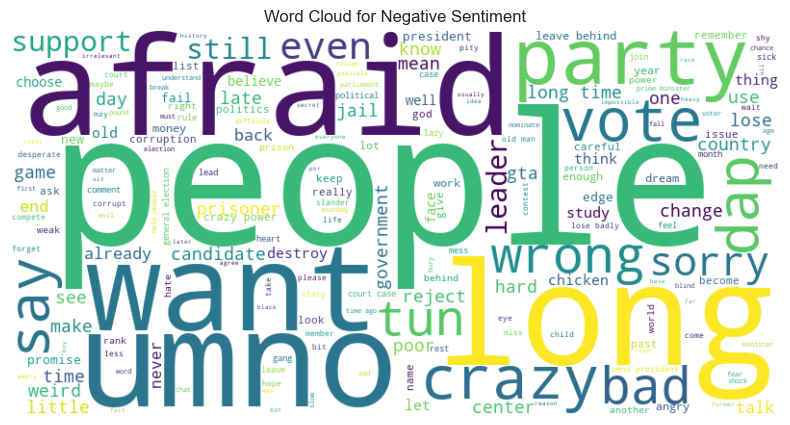

In [2]:
# Plot sentiment distributions
plot_sentiment_distribution(train_df, "Train Sentiment Distribution(ChatGPT)")
plot_sentiment_distribution(test_df, "Test Sentiment Distribution(ChatGPT)")

# Identify and print the best model based on validation F1
best_model_name = max(results, key=lambda x: results[x]['best_score'])
best_model = results[best_model_name]['model']
print(f"\n Best Model: {best_model_name} with validation F1: {results[best_model_name]['best_score']:.4f}")

# Word clouds
for sentiment in ["Positive", "Neutral", "Negative"]:
    words = train_df[train_df['Sentiment'] == sentiment]['Final_Comment'].apply(preprocess_text).sum()
    text = ' '.join(words)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Word Cloud for {sentiment} Sentiment")
    plt.show()

In [3]:
# Save each trained model
for name, res in results.items():
    model_to_save = res['model']
    filename = f"model_{name.lower()}_chatgpt.joblib"
    joblib.dump(model_to_save, filename)
    print(f"✅ Model saved: {filename}")

✅ Model saved: model_complementnb_chatgpt.joblib
✅ Model saved: model_gaussiannb_chatgpt.joblib
✅ Model saved: model_bernoullinb_chatgpt.joblib


# Save each trained model
for name, res in results.items():
    model_to_save = res['model']
    filename = f"model_{name.lower()}.joblib"
    joblib.dump(model_to_save, filename)
    print(f"✅ Model saved: {filename}")

combined_df = pd.concat(
    [
        train_df,
        test_df
    ],
    ignore_index=True
)
combined_df.to_csv('combined_sentiment_nb.csv', index=False)
print("✅ Combined sentiment dataset saved as 'combined_sentiment_nb.csv'")

combined_df = pd.concat(
    [
        pd.read_csv('train_dataset_chatgpt.csv'),
        pd.read_csv('test_dataset_chatgpt.csv')
    ],
    ignore_index=True
)
combined_df.to_csv('combined_sentiment_nb_textblob.csv', index=False)
print("✅ Combined sentiment dataset saved as 'combined_sentiment_nb_textblob.csv'")